#Proyecto Seguimiento de Clientes

##Exploración y limpieza de datos

In [2]:
#Importamos Librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Carga Del Archivo
df=pd.read_excel('/content/drive/MyDrive/Proyectos Agencia Analitica/Online Retail.xlsx',sheet_name=0)
df.head(5)

#Análisis Exploratorio de datos

df.shape #Dimension del archivo
df.info() #Tipo de datos de cada columna
df.describe() #Estadisticas de las columnas numericas
df.duplicated().sum() #Revisamos Duplicados



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


np.int64(5268)

Revisamos los duplicados, y tenemos alrededor de 5268 lo cual es alrededor de menos del 2% del dataset. Antes de decidir que vamos hacer con estos duplicados, revisamos donde estan.

In [3]:
# Ver ejemplos de duplicados reales
duplicados = df[df.duplicated(keep=False)]
print(f"Total filas duplicadas: {len(duplicados):,}")
print("\nEjemplo de duplicado:")
print(duplicados.sort_values(['CustomerID','InvoiceNo','StockCode']).head(6))

Total filas duplicadas: 10,147

Ejemplo de duplicado:
       InvoiceNo StockCode                        Description  Quantity  \
395388    571034     23239  SET OF 4 KNICK KNACK TINS POPPIES         6   
395410    571034     23239  SET OF 4 KNICK KNACK TINS POPPIES         6   
395371    571034     23245         SET OF 3 REGENCY CAKE TINS         4   
395455    571034     23245         SET OF 3 REGENCY CAKE TINS         4   
395442    571034     23494   VINTAGE DOILY DELUXE SEWING KIT          3   
395443    571034     23494   VINTAGE DOILY DELUXE SEWING KIT          3   

               InvoiceDate  UnitPrice  CustomerID Country  
395388 2011-10-13 12:47:00       4.15     12359.0  Cyprus  
395410 2011-10-13 12:47:00       4.15     12359.0  Cyprus  
395371 2011-10-13 12:47:00       4.95     12359.0  Cyprus  
395455 2011-10-13 12:47:00       4.95     12359.0  Cyprus  
395442 2011-10-13 12:47:00       5.95     12359.0  Cyprus  
395443 2011-10-13 12:47:00       5.95     12359.0  Cyprus  


In [4]:
#Eliminamos Duplicados Identicos
df.drop_duplicates()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France


In [5]:
df.nunique() #revisamos valores unicos

,0
InvoiceNo,25900
StockCode,4070
Description,4223
Quantity,722
InvoiceDate,23260
UnitPrice,1630
CustomerID,4372
Country,38


In [6]:
df_limpio=df.copy() #Creamos una copia del dataset


Revisamos los valores nulos y nos damos cuenta que tenemos una gran cantidad Customer_Id sin su respectivo identificador, abarcando alrededor del 25% del dataset


```
#df.isnull().sum() #Revisamos valores nulos
```



In [7]:
df.isnull().sum() #Revisamos valores nulos

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [8]:
#Eliminamos registros sin Customer ID
df.dropna(subset=['CustomerID'], inplace=True)
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,0
Country,0


Ahora procederemos a evaluar los Box-Plots y distribución de los datos con el objetivo de detectar valores atipicos o inusuales



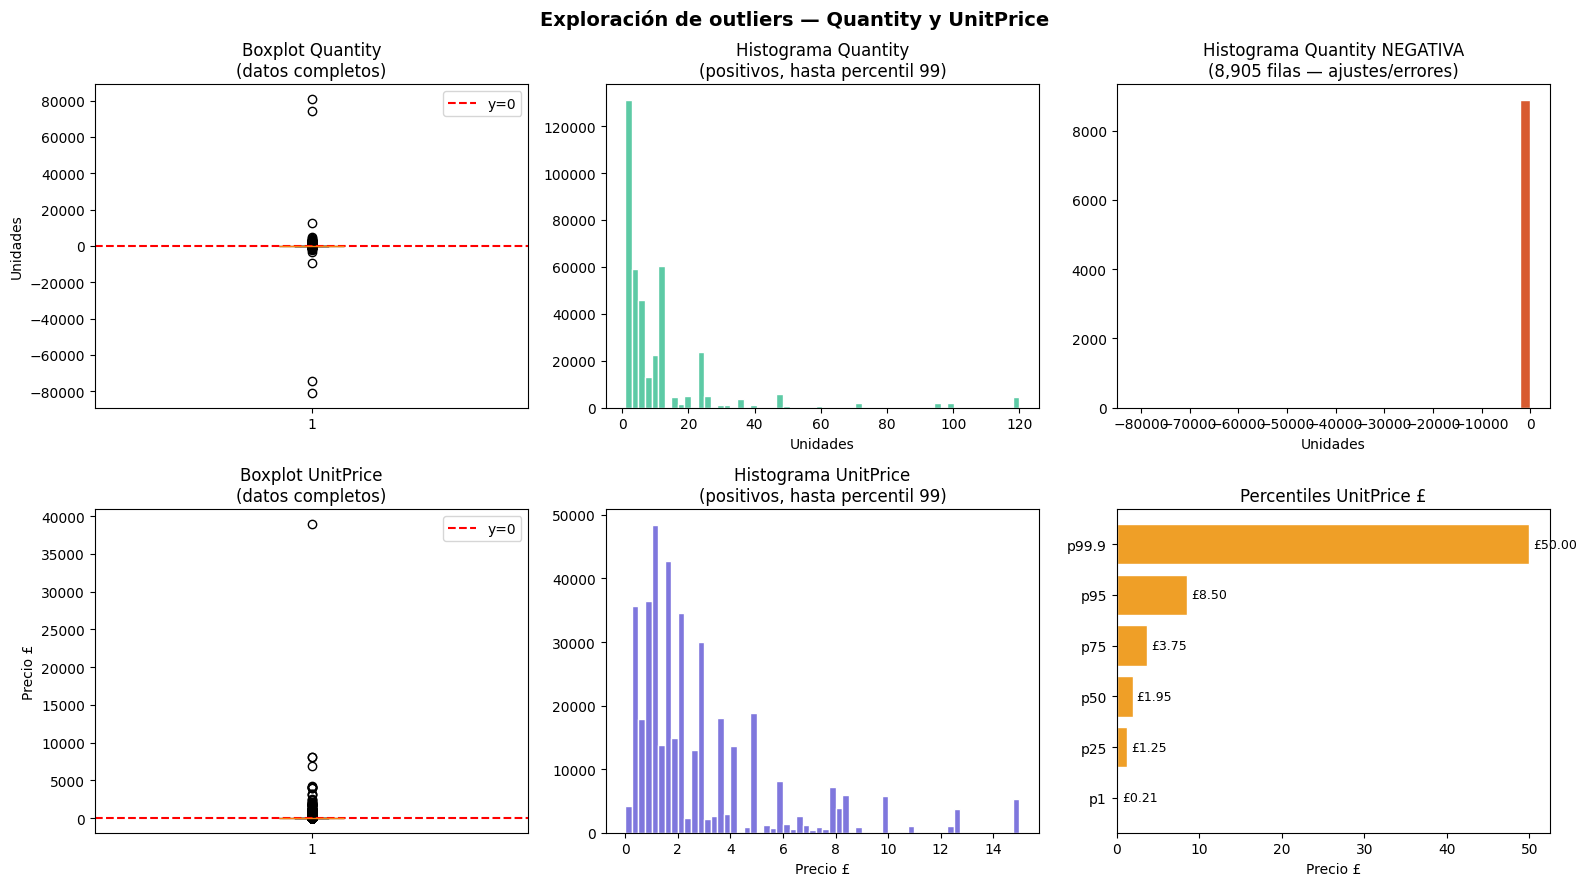


📊 Percentiles Quantity:
  p  1.0 →       -2.0 unidades
  p 25.0 →        2.0 unidades
  p 50.0 →        5.0 unidades
  p 75.0 →       12.0 unidades
  p 95.0 →       36.0 unidades
  p 99.9 →      504.0 unidades

📊 Percentiles UnitPrice:
  p  1.0 → £      0.21
  p 25.0 → £      1.25
  p 50.0 → £      1.95
  p 75.0 → £      3.75
  p 95.0 → £      8.50
  p 99.9 → £     50.00


In [9]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Exploración de outliers — Quantity y UnitPrice',
             fontsize=14, fontweight='bold')

# ── Fila 1: QUANTITY ───────────────────────────────────────────────
# Boxplot con TODOS los datos (incluyendo negativos)
axes[0,0].boxplot(df['Quantity'], vert=True, patch_artist=True,
                  boxprops=dict(facecolor='#5DCAA5', alpha=0.7))
axes[0,0].set_title('Boxplot Quantity\n(datos completos)')
axes[0,0].set_ylabel('Unidades')
axes[0,0].axhline(y=0, color='red', linestyle='--', label='y=0')
axes[0,0].legend()

# Histograma solo valores positivos
qty_pos = df[df['Quantity'] > 0]['Quantity']
axes[0,1].hist(qty_pos.clip(upper=qty_pos.quantile(0.99)),
              bins=60, color='#5DCAA5', edgecolor='white')
axes[0,1].set_title('Histograma Quantity\n(positivos, hasta percentil 99)')
axes[0,1].set_xlabel('Unidades')

# Histograma valores NEGATIVOS (devoluciones no filtradas aún)
qty_neg = df[df['Quantity'] < 0]['Quantity']
axes[0,2].hist(qty_neg, bins=40, color='#D85A30', edgecolor='white')
axes[0,2].set_title(f'Histograma Quantity NEGATIVA\n({len(qty_neg):,} filas — ajustes/errores)')
axes[0,2].set_xlabel('Unidades')

# ── Fila 2: UNITPRICE ──────────────────────────────────────────────
# Boxplot con todos los datos
axes[1,0].boxplot(df['UnitPrice'], vert=True, patch_artist=True,
                  boxprops=dict(facecolor='#7F77DD', alpha=0.7))
axes[1,0].set_title('Boxplot UnitPrice\n(datos completos)')
axes[1,0].set_ylabel('Precio £')
axes[1,0].axhline(y=0, color='red', linestyle='--', label='y=0')
axes[1,0].legend()

# Histograma UnitPrice positivos hasta percentil 99
price_pos = df[df['UnitPrice'] > 0]['UnitPrice']
axes[1,1].hist(price_pos.clip(upper=price_pos.quantile(0.99)),
              bins=60, color='#7F77DD', edgecolor='white')
axes[1,1].set_title('Histograma UnitPrice\n(positivos, hasta percentil 99)')
axes[1,1].set_xlabel('Precio £')

# Percentiles clave para decidir umbrales
percentiles = [1,25, 50, 75, 95, 99.9]
qty_pcts  = np.percentile(df['Quantity'],  percentiles)
price_pcts = np.percentile(df['UnitPrice'], percentiles)
axes[1,2].barh([f'p{p}' for p in percentiles], price_pcts,
              color='#EF9F27', edgecolor='white')
axes[1,2].set_title('Percentiles UnitPrice £')
axes[1,2].set_xlabel('Precio £')
for i, v in enumerate(price_pcts):
    axes[1,2].text(v + 0.5, i, f'£{v:.2f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('outliers_exploracion.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Tabla de percentiles en consola ───────────────────────────────
print("\n📊 Percentiles Quantity:")
for p, v in zip(percentiles, qty_pcts):
    print(f"  p{p:5.1f} → {v:>10.1f} unidades")

print("\n📊 Percentiles UnitPrice:")
for p, v in zip(percentiles, price_pcts):
    print(f"  p{p:5.1f} → £{v:>10.2f}")

Revisamos que hay unos outliers, pero pueden deberse a la dinamica del producto. Sin embargo, eliminamos los datos de las columnas númericas que estan por debajo de 0, ya que estos si pueden ser errores

In [10]:
antes = len(df)
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]
print(f"🗑️  Qty/Price inválidos:         {antes - len(df):,} filas")

🗑️  Qty/Price inválidos:         8,945 filas


In [11]:
# 4e. Convertir CustomerID a entero
df['CustomerID'] = df['CustomerID'].astype(int)

# 4f. Crear columna TotalPrice
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

In [12]:
df.shape
df['CustomerID'].nunique()

4338

##Calculo - Análisis RFM

El análisis RFM es una técnica de segmentación de clientes basada en su comportamiento de compra histórico. Es una herramienta fundamental en Data Analytics y Business Intelligence para entender quiénes son tus clientes más valiosos y cómo interactúan con tu negocio.

Buscamos responder preguntas tipo "¿Con qué frecuencia compra el cliente?" y "¿Cuánto dinero ha gastado el cliente en total?"

In [13]:
#Fecha de referencia
fecha_ref = df['InvoiceDate'].max() + pd.Timedelta(days=1)
print(f"Fecha de referencia: {fecha_ref.date()}\n")

Fecha de referencia: 2011-12-10



In [14]:
#Cuantos dias desde su ultima compra?
# ── Calcular R, F, M por cliente ───────────────────────────────────
rfm = df.groupby('CustomerID').agg(
    Recency   = ('InvoiceDate', lambda x: (fecha_ref - x.max()).days),
    Frequency = ('InvoiceNo',   'nunique'),
    Monetary  = ('TotalPrice',  'sum')
).reset_index()

print(f"\n✅ Clientes en tabla RFM: {len(rfm):,}")
print(f"\n📊 Estadísticas descriptivas:")
print(rfm[['Recency','Frequency','Monetary']].describe().round(2))
rfm.head(5)


✅ Clientes en tabla RFM: 4,338

📊 Estadísticas descriptivas:
       Recency  Frequency   Monetary
count  4338.00    4338.00    4338.00
mean     92.54       4.27    2054.27
std     100.01       7.70    8989.23
min       1.00       1.00       3.75
25%      18.00       1.00     307.41
50%      51.00       2.00     674.48
75%     142.00       5.00    1661.74
max     374.00     209.00  280206.02


,CustomerID,Recency,Frequency,Monetary
0,12346,326,1,77183.60
1,12347,2,7,4310.00
2,12348,75,4,1797.24
3,12349,19,1,1757.55
4,12350,310,1,334.40


Entre menos días es mejor el Recency, por ende le damos un puntaje alto

In [15]:
#Puntaje por cuartiles
#Recency = Cuartil bajo = Mejor Score
rfm['R_Puntaje']=pd.qcut(rfm['Recency'], q=4, labels=[4,3,2,1])

#Frecuency y Monetary = Mayor Cuartil = Mejor Score
rfm['F_Puntaje']=pd.qcut(rfm['Frequency'].rank(method='first'), q=4, labels=[1,2,3,4])
rfm['M_Puntaje']=pd.qcut(rfm['Monetary'], q=4, labels=[1,2,3,4])

#Puntaje combinado y total
rfm['RFM_Puntaje']=rfm['R_Puntaje'].astype(str)+rfm['F_Puntaje'].astype(str)+rfm['M_Puntaje'].astype(str)
rfm['RFM_Total']=rfm['R_Puntaje'].astype(int)+rfm['F_Puntaje'].astype(int)+rfm['M_Puntaje'].astype(int)


In [16]:
#Segmentamos los clientes
def segmentar(row):
    r = int(row['R_Puntaje'])
    f = int(row['F_Puntaje'])
    if   r >= 4 and f >= 4: return 'Campeones'
    elif r >= 3 and f >= 3: return 'Leales'
    elif r >= 4 and f <= 2: return 'Nuevos'
    elif r >= 3 and f <= 2: return 'Potenciales'
    elif r <= 2 and f >= 3: return 'En riesgo'
    elif r == 1 and f >= 4: return 'Hibernando'
    else:                    return 'Perdidos'

rfm['Segmento'] = rfm.apply(segmentar, axis=1)

In [17]:
print("---Resumen de segmentos---")
print(rfm['Segmento'].value_counts().to_string())

---Resumen de segmentos---
Segmento
Perdidos       1504
Leales          914
En riesgo       646
Campeones       609
Potenciales     431
Nuevos          234


In [18]:
#Guardamos la tabla RFM
rfm.to_csv('rfm_clientes.csv', index=False)
print("\n💾 Guardado: rfm_clientes.csv")


💾 Guardado: rfm_clientes.csv


In [19]:
resumen = rfm.groupby('Segmento').agg(
    Clientes  = ('CustomerID', 'count'),
    Recency   = ('Recency',    'mean'),
    Frequency = ('Frequency',  'mean'),
    Monetary  = ('Monetary',   'mean')
).round(1)
print("\n📊 Resumen por segmento:")
print(resumen.to_string())


📊 Resumen por segmento:
             Clientes  Recency  Frequency  Monetary
Segmento                                           
Campeones         609      7.6       13.7    7517.9
En riesgo         646    119.2        4.2    1611.4
Leales            914     24.5        5.1    2213.3
Nuevos            234     10.0        1.6    1229.4
Perdidos         1504    186.6        1.3     510.1
Potenciales       431     33.5        1.4     497.2


**Observaciones con respecto a la tabla de segmentos**
Dividimos en 6 clases a nuestros clientes, siendo campeones la mejor considerecion y perdidos la peor.

Campeones: Son clientes que compraron hace poco, pero que lo hacen bastante seguido y monetariamente hacen buenas compras

Leales (914 clientes) — El grupo más grande después de Perdidos. Buenos en frecuencia y gasto, pero con 24 días de recency todavía manejable.

En riesgo (646 clientes) — Aquí está el problema. Compraban con frecuencia (4.2 veces) y gastaban decente (£1,611), pero llevan 119 días sin comprar. Estos son clientes que había que recuperar.

Perdidos (1,504 clientes) — El grupo más grande. 186 días sin comprar, solo 1.3 compras, £510. Probablemente compraron una sola vez y nunca volvieron.

**Nuevos** (234) y **Potenciales** (431) — Recency reciente pero poca frecuencia. Clientes que hay que nutrir.



##Clustering - Kmeans

El clustering es una técnica de machine learning no supervisado que agrupa automáticamente datos similares, mientras que el RFM (Recencia, Frecuencia, Valor Monetario) segmenta clientes basándose en tres métricas de compra predefinidas. El clustering encuentra patrones ocultos, mientras que el RFM clasifica con reglas de negocio claras

Para realizar clustering, se deben normalizar las variables numericas y las variables categoricas se  vuelven númericas mediante la creacion de dummies. Sin embargo en este ejercicio aplicaremos soble la tabla RFM construida en la fase anterior.

**¿Por qué?**

El dataset original tiene ~397,884 filas — una por cada producto comprado.
Aplicar K-Means ahí significaría agrupar *transacciones*, no clientes,
lo cual no tiene sentido de negocio.

Lo que queremos es responder: **¿a qué grupo pertenece cada cliente?**
Y para eso necesitamos una fila por cliente con sus métricas resumidas

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Volver a cargar el CSV original sin escalar
rfm = pd.read_csv('/content/rfm_clientes.csv')

# Guardar el escalado en columnas NUEVAS
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency','Frequency','Monetary']])
rfm_scaled = pd.DataFrame(rfm_scaled,
                           columns=['R_scaled','F_scaled','M_scaled'])

# Verificar que los originales siguen intactos
print("Originales intactos:")
print(rfm[['Recency','Frequency','Monetary']].describe().round(1))

print("\nEscalados (para K-Means):")
print(rfm_scaled.describe().round(2))

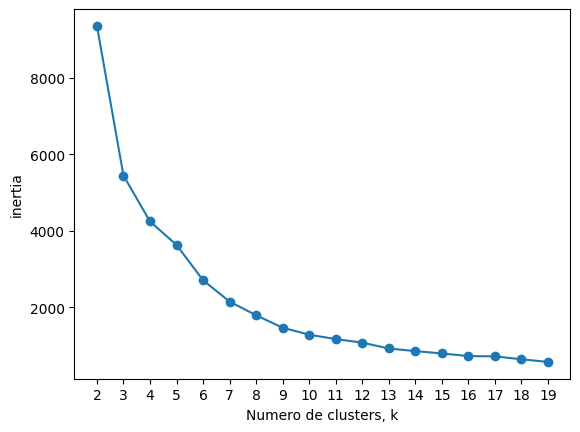

In [21]:
#Método del codo para encontrar la mejor cantidad de clusters: inertia
from sklearn.cluster import KMeans

ks = range(2, 20) # crear valores del 2 al 20
inertias = []

for k in ks:
    # Crear  modelo
    model = KMeans(n_clusters=k,max_iter=300)
    model.fit(rfm_scaled)
    inertias.append(model.inertia_)

# Graficar cantidad de clusters vs inertias
plt.plot(ks, inertias, '-o')
plt.xlabel('Numero de clusters, k')
plt.ylabel('inertia')
plt.xticks(ks)
plt.show()

In [ ]:

K_ELEGIDO = 4

km_final = KMeans(n_clusters=K_ELEGIDO, random_state=42, n_init=10)
rfm['Cluster'] = km_final.fit_predict(rfm_scaled)

print(f"✅ K-Means aplicado con K={K_ELEGIDO}")
print(f"\nClientes por cluster:")
print(rfm['Cluster'].value_counts().sort_index())

# ── Perfil de cada cluster ─────────────────────────────────────────
perfil = rfm.groupby('Cluster')[['Recency','Frequency','Monetary']].mean().round(1)
print("\n📊 Perfil promedio por cluster:")
print(perfil)

In [23]:
nombres = {
    0: 'Ocasionales',
    1: 'Perdidos',
    2: 'Frecuentes',
    3: 'VIP'
}

rfm['Cluster_nombre'] = rfm['Cluster'].map(nombres)

print(rfm['Cluster_nombre'].value_counts())

rfm.to_csv('rfm_clientes.csv', index=False)
print("\n💾 rfm_clientes.csv actualizado con clusters")

Cluster_nombre
Ocasionales    3054
Perdidos       1067
VIP             204
Frecuentes       13
Name: count, dtype: int64

💾 rfm_clientes.csv actualizado con clusters


In [24]:
#Evaluación

from sklearn import metrics



#Inertia: se require valor pequeño

print('Inercia o cohesión:', model.inertia_)



#Silueta: se requiere que sea positivo, ideal 0.5-1.0

sil=metrics.silhouette_score(rfm_scaled, model.labels_)

print('Silueta:',sil)

Inercia o cohesión: 570.8000341365637
Silueta: 0.34650421610075904


La baja silueta no invalida el análisis. En datasets de comportamiento
de compra los clientes no forman clusters geométricamente perfectos.
Los 4 segmentos son interpretables y accionables desde el negocio,
que es el objetivo real del análisis RFM.

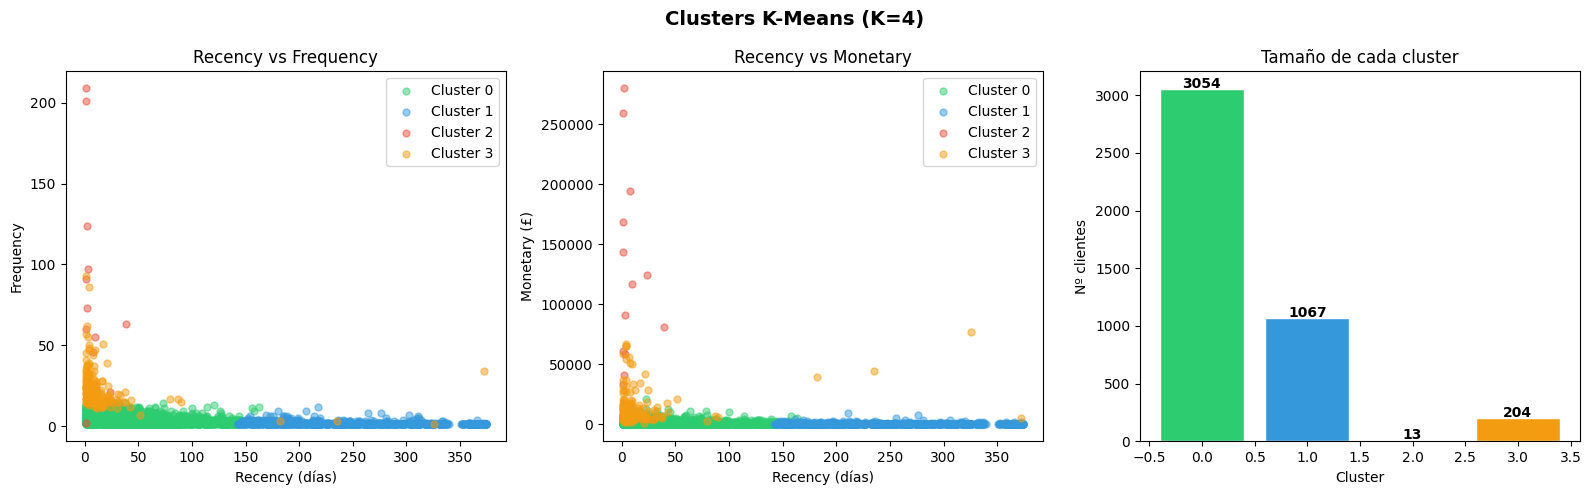

In [25]:
import matplotlib.pyplot as plt

colores_cluster = ['#2ecc71', '#3498db', '#e74c3c', '#f39c12',
                   '#9b59b6', '#1abc9c', '#e67e22']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(f'Clusters K-Means (K={K_ELEGIDO})', fontsize=14, fontweight='bold')

# Scatter 1: Recency vs Frequency
for c in sorted(rfm['Cluster'].unique()):
    mask = rfm['Cluster'] == c
    axes[0].scatter(rfm[mask]['Recency'], rfm[mask]['Frequency'],
                   label=f'Cluster {c}', alpha=0.5, s=25,
                   color=colores_cluster[c])
axes[0].set_xlabel('Recency (días)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Recency vs Frequency')
axes[0].legend()

# Scatter 2: Recency vs Monetary
for c in sorted(rfm['Cluster'].unique()):
    mask = rfm['Cluster'] == c
    axes[1].scatter(rfm[mask]['Recency'], rfm[mask]['Monetary'],
                   label=f'Cluster {c}', alpha=0.5, s=25,
                   color=colores_cluster[c])
axes[1].set_xlabel('Recency (días)')
axes[1].set_ylabel('Monetary (£)')
axes[1].set_title('Recency vs Monetary')
axes[1].legend()

# Barras: tamaño de cada cluster
conteo = rfm['Cluster'].value_counts().sort_index()
axes[2].bar(conteo.index, conteo.values,
           color=colores_cluster[:K_ELEGIDO], edgecolor='white')
axes[2].set_xlabel('Cluster')
axes[2].set_ylabel('Nº clientes')
axes[2].set_title('Tamaño de cada cluster')
for i, v in enumerate(conteo.values):
    axes[2].text(i, v + 10, f'{v}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('clusters_visualizacion.png', dpi=150, bbox_inches='tight')
plt.show()

##Predicción de Churn

El churn o churn rate (tasa de cancelación) es la métrica que indica el porcentaje de clientes que dejan de utilizar los servicios o productos de una empresa en un periodo determinado. Es un indicador clave de la satisfacción del cliente y la salud financiera.

La logica que usaremos es: Si un cliente lleva más de X días sin comprar → lo etiquetamos como Churn = 1
Si un cliente compró recientemente           → Churn = 0 **texto en negrita**

In [35]:

rfm = pd.read_csv('rfm_clientes.csv')

# ── Umbral basado en percentiles de Recency ────────────────────────
# p75 = 142 días → usamos 180 días como umbral conservador
UMBRAL_CHURN = 180

rfm['Churn'] = (rfm['Recency'] > UMBRAL_CHURN).astype(int)

# ── Diagnóstico ────────────────────────────────────────────────────
total    = len(rfm)
churn_1  = rfm['Churn'].sum()
churn_0  = total - churn_1

print(f"Umbral de churn: {UMBRAL_CHURN} días sin comprar")
print(f"\nChurn = 1 (se fue):    {churn_1:,}  ({churn_1/total*100:.1f}%)")
print(f"Churn = 0 (activo):    {churn_0:,}  ({churn_0/total*100:.1f}%)")
print(f"\nVerificación cruzada con clusters:")
print(rfm.groupby(['Cluster_nombre', 'Churn'])['CustomerID'].count().unstack())

Umbral de churn: 180 días sin comprar

Churn = 1 (se fue):    860  (19.8%)
Churn = 0 (activo):    3,478  (80.2%)

Verificación cruzada con clusters:
Churn                0      1
Cluster_nombre               
Frecuentes        13.0    NaN
Ocasionales     3054.0    NaN
Perdidos         211.0  856.0
VIP              200.0    4.0


### Primera versión — Data Leakage
La siguiente celda incluye Recency como feature. Se mantiene para
ilustrar el error. Los resultados perfectos (AUC=1.0) son la señal
que delata el problema.

In [36]:
#Modelo predictivo
#Preparar feature y dividir Train y Test
from sklearn.model_selection import train_test_split

# ── Features y variable objetivo ───────────────────────────────────
FEATURES = ['Recency', 'Frequency', 'Monetary', 'Cluster']

X = rfm[FEATURES]
y = rfm['Churn']

# ── División 80% entrenamiento / 20% prueba ────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Entrenamiento: {len(X_train):,} clientes")
print(f"Prueba:        {len(X_test):,} clientes")
print(f"\nProporción churn en entrenamiento: {y_train.mean():.1%}")
print(f"Proporción churn en prueba:        {y_test.mean():.1%}")

Entrenamiento: 3,470 clientes
Prueba:        868 clientes

Proporción churn en entrenamiento: 19.8%
Proporción churn en prueba:        19.8%


In [37]:
#Entrenar Random Forest
from sklearn.ensemble import RandomForestClassifier
bosque=RandomForestClassifier(n_estimators=100,
                              criterion="gini",
                              random_state=42,
                              class_weight='balanced')
bosque.fit(X_train, y_train)
print("✅ Modelo entrenado")

✅ Modelo entrenado


In [38]:
#Predicciones
y_pred      = bosque.predict(X_test)
y_pred_prob = bosque.predict_proba(X_test)[:, 1]  # probabilidad de churn

print(f"\nEjemplo — primeras 5 predicciones:")
for i in range(5):
    print(f"  Real: {y_test.iloc[i]}  →  Predicho: {y_pred[i]}  "
          f"(prob churn: {y_pred_prob[i]:.2f})")


Ejemplo — primeras 5 predicciones:
  Real: 0  →  Predicho: 0  (prob churn: 0.00)
  Real: 0  →  Predicho: 0  (prob churn: 0.00)
  Real: 0  →  Predicho: 0  (prob churn: 0.00)
  Real: 1  →  Predicho: 1  (prob churn: 1.00)
  Real: 0  →  Predicho: 0  (prob churn: 0.00)


📊 Reporte de clasificación:
              precision    recall  f1-score   support

  Activo (0)       1.00      1.00      1.00       696
   Churn (1)       1.00      1.00      1.00       172

    accuracy                           1.00       868
   macro avg       1.00      1.00      1.00       868
weighted avg       1.00      1.00      1.00       868

AUC-ROC: 1.0000


Text(0.5, 1.0, 'Matriz de Confusión')

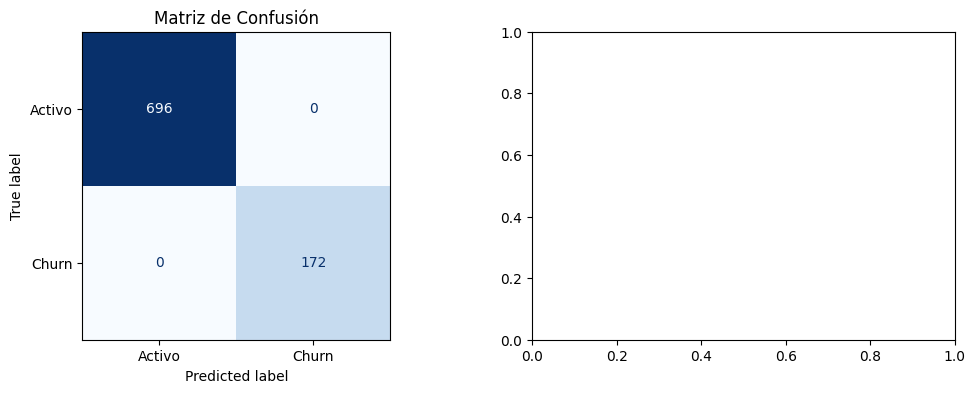

In [39]:
#Evaluación del Modelo
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, ConfusionMatrixDisplay)
import matplotlib.pyplot as plt

# ── Métricas principales ───────────────────────────────────────────
print("📊 Reporte de clasificación:")
print(classification_report(y_test, y_pred,
      target_names=['Activo (0)', 'Churn (1)']))

auc = roc_auc_score(y_test, y_pred_prob)
print(f"AUC-ROC: {auc:.4f}")

# ── Matriz de confusión ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, ax=axes[0],
    display_labels=['Activo', 'Churn'],
    colorbar=False, cmap='Blues'
)
axes[0].set_title('Matriz de Confusión')


Aquí vemos algo curioso, y es que nuestras metricas de evaluación estan perfectas. Algo bastante inusual y se debe a que el modelo esta haciendo "trampa" ya que esta no esta aprendiendo si no memorizando una regla. El modelo simplemente aprendió la regla
if Recency > 180 → Churn = 1. No aprendió nada útil — solo memorizó la fórmula que tú mismo le diste. Es como darle la respuesta en el examen.

Al incluir **Recency** como feature, el modelo aprendió
únicamente la regla:

```
if Recency > 180 → predecir Churn = 1
```

Esto produjo métricas perfectas (Accuracy=1.0, AUC=1.0),
lo cual es una señal de alerta, no de éxito.

### ¿Cómo se corrige?

Eliminar **Recency** de los features. El modelo debe predecir
el churn basándose en el comportamiento de compra del cliente
(frecuencia y gasto), no en la misma variable que define el churn.

In [40]:
#Reentrenamos el modelo
#Features sin Recency
FEATURES = ['Frequency', 'Monetary', 'Cluster']

X = rfm[FEATURES]
y = rfm['Churn']

X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42, stratify=y)

bosque = RandomForestClassifier(
    n_estimators = 200,
    max_depth    = 6,
    random_state = 42,
    class_weight = 'balanced'
)

bosque.fit(X_train, y_train)
print("✅ Modelo reentrenado sin Recency")

✅ Modelo reentrenado sin Recency


In [41]:
y_pred      = bosque.predict(X_test)
y_pred_prob = bosque.predict_proba(X_test)[:, 1]  # probabilidad de churn

📊 Reporte de clasificación:
              precision    recall  f1-score   support

  Activo (0)       1.00      0.93      0.96       696
   Churn (1)       0.78      0.99      0.87       172

    accuracy                           0.94       868
   macro avg       0.89      0.96      0.92       868
weighted avg       0.95      0.94      0.95       868

AUC-ROC: 0.9755


Text(0.5, 1.0, 'Matriz de Confusión')

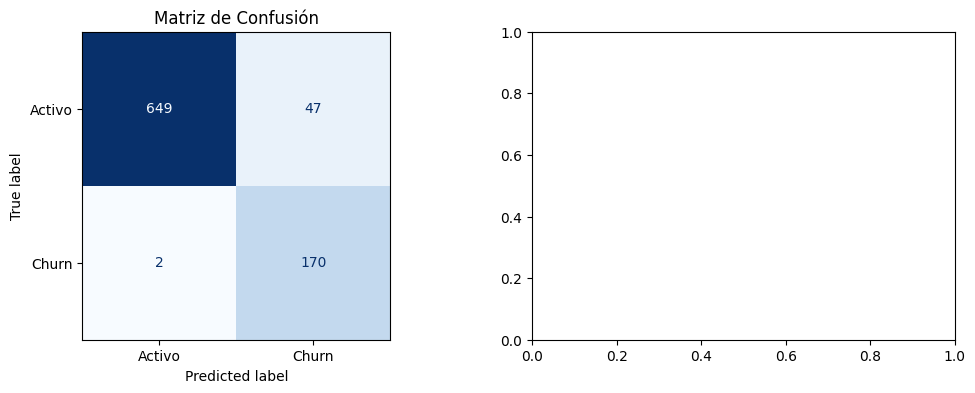

In [42]:
#Evaluación del Modelo
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, ConfusionMatrixDisplay)
import matplotlib.pyplot as plt

# ── Métricas principales ───────────────────────────────────────────
print("📊 Reporte de clasificación:")
print(classification_report(y_test, y_pred,
      target_names=['Activo (0)', 'Churn (1)']))

auc = roc_auc_score(y_test, y_pred_prob)
print(f"AUC-ROC: {auc:.4f}")

# ── Matriz de confusión ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, ax=axes[0],
    display_labels=['Activo', 'Churn'],
    colorbar=False, cmap='Blues'
)
axes[0].set_title('Matriz de Confusión')

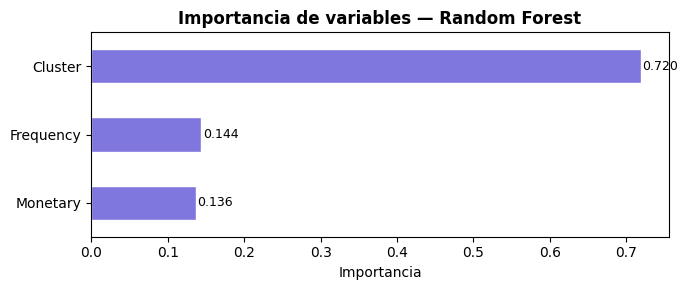

In [44]:
#Importancia de las variables
importancias = pd.Series(bosque.feature_importances_, index=FEATURES).sort_values()

fig, ax = plt.subplots(figsize=(7, 3))
importancias.plot(kind='barh', ax=ax, color='#7F77DD', edgecolor='white')
ax.set_title('Importancia de variables — Random Forest', fontweight='bold')
ax.set_xlabel('Importancia')
for i, v in enumerate(importancias.values):
    ax.text(v + 0.002, i, f'{v:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

### Interpretación de la importancia de variables

El Cluster domina con 72% porque es una variable derivada que ya
resume el comportamiento RFM completo del cliente. En cierta forma,
el modelo está usando los resultados del clustering para predecir churn,
lo que explica su alto AUC (0.9755) aun sin Recency.

Frequency y Monetary contribuyen con ~14% cada una, confirmando que
el volumen y valor de compras tienen poder predictivo independiente
del cluster asignado.

In [43]:
# ── Agregar probabilidad de churn a todos los clientes ────────────
rfm['Churn_prob'] = bosque.predict_proba(X)[:, 1]
rfm['Churn_pred'] = bosque.predict(X)

rfm.to_csv('rfm_clientes.csv', index=False)
print("\n💾 rfm_clientes.csv actualizado con Churn_prob")


💾 rfm_clientes.csv actualizado con Churn_prob


##Resultados y Recomendaciones
**Resultados:** tenemos unos resultados muy buenos, con una precisión del 0.94 lo que dice que el modelo clasifica correctamente 94 clientes de 100. ademas de un recall de 0.99 lo que significa que detecta muy bien a los clientes que se van a ir y en temas de retención de cliente eso es muy importante.

**Recomendaciones:** El 34% de los clientes están perdidos (1,504 de 4,338) y el grupo más grande del clustering son también los perdidos. Esto indica un problema estructural de retención — el negocio adquiere clientes pero no los fideliza. La prioridad estratégica no debería ser conseguir nuevos clientes sino retener los existentes, que ya conocen la marca y tienen historial de compra.

El modelo detecta el 99% de los churners. Esto permite:
Acción inmediata — tomar el top 10 de clientes activos con mayor probabilidad de churn y contactarlos esta semana antes de que se vayan.
Acción mensual — correr el modelo cada mes sobre clientes activos y generar una lista priorizada para el equipo comercial.